# Inference and Throughput Analysis

This Jupyter notebook allows us to check various metrics of the inference results obtained from our model. 

In [44]:
#Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.dataloading import get_data_urls
plt.rcParams["font.family"] = "serif"

This repository contains example data from a previous test on the dataset used to train the final model. 

The data containing the ground-truth labels can be found in the `camera_data` folder under the name `training_set_cameras_data.csv`

The results from inference can be found in the `outputs` folder under the names `inference_results_example.csv` and `throughput_results_example.csv`.

If you wish to analyze the model's results on a different dataset, follow these steps:

1) Ensure you have a dataset in the proper format. Two additional datasets, `coronado_hills_data.csv` and `unseen_cameras_data.csv` are provided in the `camera_data` folder.

2) Run `run_inference.py` to obtain inference and throughput results. It is recommended to let the script run using its default behavior, but if you wish to change this, you can view the documentation for the arguments by running `python run_inference.py -h`

3) Set `use_example_data` to False below and change the value of `data_fp` as indicated below.

In [45]:
use_example_data = False #Set this to False if you want to use different data 

if use_example_data:
    throughput_fp = "outputs/throughput_results_example.csv"
    inference_fp = "outputs/inference_results_example.csv"
    data_fp  = "camera_data/training_set_cameras_data.csv"
else:
    throughput_fp = "outputs/throughput_results.csv"
    inference_fp = "outputs/inference_results.csv"
    data_fp  = "camera_data/unseen_cameras_data.csv" #Set this to the dataset you used when running run_inference.py. The default is "camera_data/training_set_cameras_data.csv"

## Throughput Analysis

Below, we load and visualize the throughput results from `run_inference.py`. The example data contains the results from various batch sizes; if you wish to emulate this, you can run `run_inference.py` multiple times, using different batch sizes each run.

In [46]:
throughput_data = pd.read_csv(throughput_fp, names = ["Batch Size", "Time Per Batch (Loading)", 
                                                      "Time Per Batch (Inference)", 
                                                      "Total Time Per Batch", "Overall Total"]).sort_values("Batch Size")
throughput_data.head()

,Batch Size,Time Per Batch (Loading),Time Per Batch (Inference),Total Time Per Batch,Overall Total
0,32,5.7908,8.8864,14.6772,308.2204


Text(0.5, 1.0, 'Inference Time per Batch')

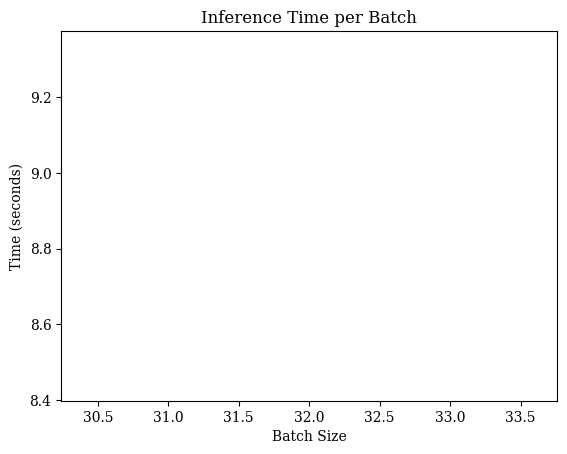

In [47]:
import matplotlib.font_manager as font_manager

font = font_manager.FontProperties(
    family='serif', # Specify font family
    weight='normal',         # Set font weight (e.g., 'normal', 'bold', 'light')
    style='normal',        # Set font style (e.g., 'normal', 'italic', 'oblique')
    size=10               # Set font size
)


plt.plot(throughput_data["Batch Size"], throughput_data["Time Per Batch (Inference)"], 
         color = "blue", lw = 2.5)
plt.xlabel("Batch Size", fontname = "serif")
plt.ylabel("Time (seconds)" , fontname = "serif")
plt.title("Inference Time per Batch", fontname = "serif")

## Inference Analysis

Below, we load and visualize the Inference results from `run_inference.py`. The data originally comes from `training_set_cameras_data.csv`. The dataset should match the one used in `run_inference.py`; if you changed it there, make the same change here.

In [48]:
#Loading results from inference
inference_data = pd.read_csv(inference_fp, sep = ",", header = None, names = ["id", "img_url", "img_path", "predicted_label", "predicted_label_name"])
inference_data.head()

,id,img_url,img_path,predicted_label,predicted_label_name
0,1125704,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125704.jpg,1,Abnormal
1,1125723,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125723.jpg,0,Normal
2,1125735,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125735.jpg,1,Abnormal
3,1125800,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125800.jpg,1,Abnormal
4,1125822,https://tools.alertcalifornia.org/fireframes5/...,camera_data/images/img_1125822.jpg,0,Normal


In [49]:
#Loading and processing ground truth data
camera_data = get_data_urls(data_fp, binarize = True, include_location=True)
camera_data.to_csv("camera_data/necessary_camera_data.csv", index = False)

In [50]:
#Helper function to view confusion matrix
def plot_confusion_matrix(true_labels, pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title, fontname = "serif")
    plt.show()

Below, we merge the inference and ground-truth data together and plot the resulting confusion matrices for each camera in the dataset.

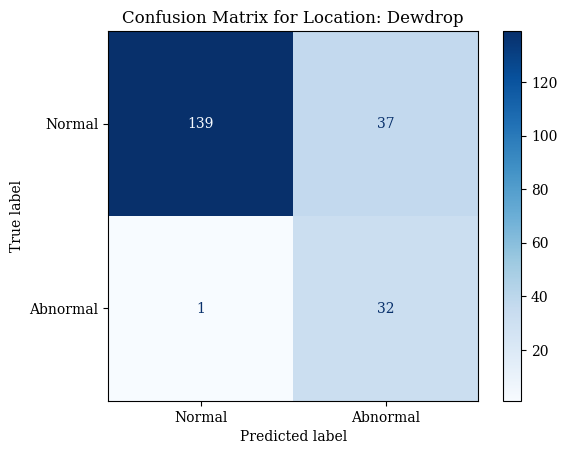

Accuracy for Dewdrop: 0.8182


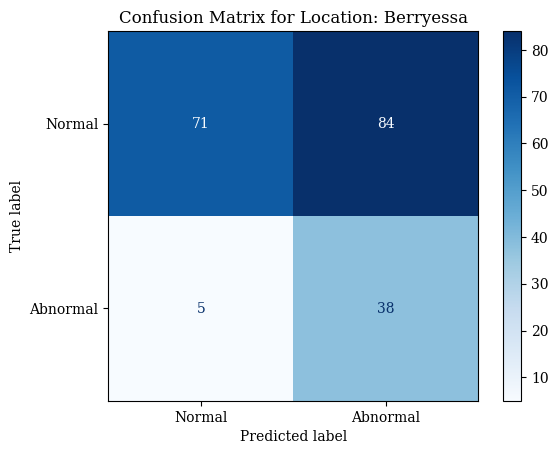

Accuracy for Berryessa: 0.5505


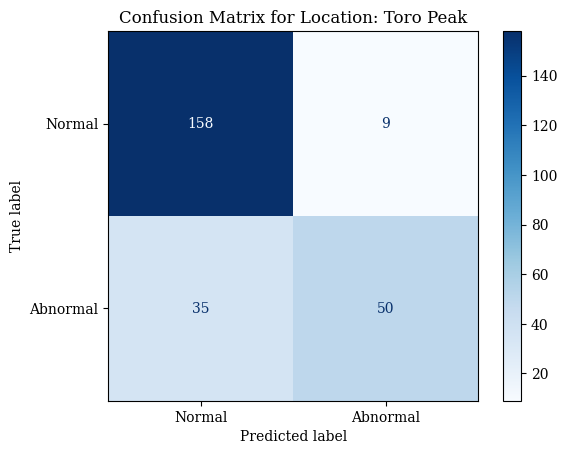

Accuracy for Toro Peak: 0.8254


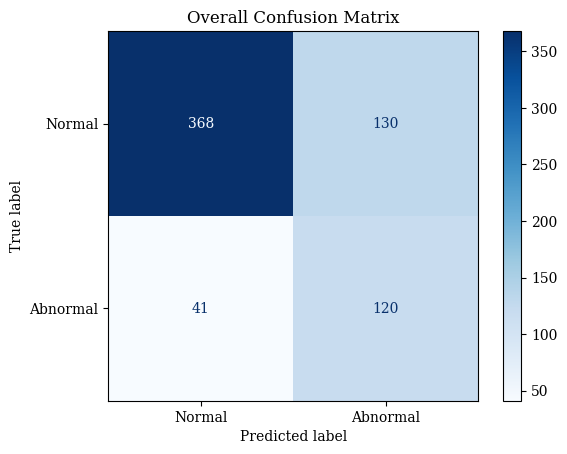

Overall Accuracy: 0.7405


In [51]:
choice_and_predictions = pd.merge(camera_data, inference_data, left_on = "id", right_on = "id", how = "inner")

for location in choice_and_predictions["location"].unique():
    subset = choice_and_predictions[choice_and_predictions["location"] == location]
    plot_confusion_matrix(subset['choice'], subset['predicted_label'], title=f"Confusion Matrix for Location: {location}")
    print(f"Accuracy for {location}: {(subset['choice'] == subset['predicted_label']).mean():.4f}")

plot_confusion_matrix(choice_and_predictions['choice'], choice_and_predictions['predicted_label'], title=f"Overall Confusion Matrix")
print(f"Overall Accuracy: {(choice_and_predictions['choice'] == choice_and_predictions['predicted_label']).mean():.4f}")